**CELL 1 — Install + mount + set path (run once per runtime)**

In [1]:
from google.colab import drive
drive.mount("/content/drive")

BASE="/content/drive/MyDrive/AI_Trichologist"
import os, sys
sys.path.insert(0, BASE) if BASE not in sys.path else None
os.makedirs(f"{BASE}/modules", exist_ok=True)
open(f"{BASE}/modules/__init__.py","a").close()
print("READY:", BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
READY: /content/drive/MyDrive/AI_Trichologist


In [2]:
!pip -q uninstall -y mediapipe
!pip -q install mediapipe==0.10.14

In [3]:
import mediapipe as mp, inspect, os, sys
print("mediapipe module file:", getattr(mp, "__file__", None))
print("has solutions?", hasattr(mp, "solutions"))
print("dir head:", list(dir(mp))[:30])

mediapipe module file: /usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py
has solutions? True
dir head: ['CalculatorGraph', 'GraphInputStreamAddMode', 'Image', 'ImageFormat', 'ImageFrame', 'Matrix', 'Packet', 'Timestamp', 'ValidatedGraphConfig', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'calculators', 'model_ckpt_util', 'packet_creator', 'packet_getter', 'resource_util', 'solutions', 'tasks']


**CELL 4 — Restart runtime (MANDATORY)**

In [ ]:
import os, signal
os.kill(os.getpid(), signal.SIGKILL)

**CELL 5 — Write UPDATED phase3_segmentation.py (WITH FaceDetection fallback)**

In [28]:
%%writefile /content/drive/MyDrive/AI_Trichologist/modules/phase3_segmentation.py
from __future__ import annotations
import os, json
from dataclasses import dataclass
from typing import Any, Dict, Optional, Tuple

import cv2
import numpy as np
import mediapipe as mp

def _read_json(p):
    with open(p,"r",encoding="utf-8") as f: return json.load(f)

def _write_json(p,obj):
    tmp=p+".tmp"
    with open(tmp,"w",encoding="utf-8") as f: json.dump(obj,f,ensure_ascii=False,indent=2)
    os.replace(tmp,p)

def _ensure_dir(p): os.makedirs(p, exist_ok=True)

def _clip_bbox_xyxy(x1,y1,x2,y2,w,h):
    x1=max(0,min(x1,w-1)); y1=max(0,min(y1,h-1))
    x2=max(0,min(x2,w-1)); y2=max(0,min(y2,h-1))
    if x2<=x1: x2=min(w-1,x1+1)
    if y2<=y1: y2=min(h-1,y1+1)
    return x1,y1,x2,y2

def _maybe_denorm(v,size):
    v=float(v)
    return int(round(v*size)) if 0.0<=v<=1.0 else int(round(v))

def _extract_face_bbox_xyxy(geometry: Dict[str,Any], img_w:int, img_h:int)->Optional[Tuple[int,int,int,int]]:
    keys=["face_bbox","bbox","face_box","faceRect","face_rect","face","rect","roi"]
    def parse(d):
        if not isinstance(d,dict): return None
        if all(k in d for k in ("x","y","w","h")):
            x=_maybe_denorm(d["x"],img_w); y=_maybe_denorm(d["y"],img_h)
            w=_maybe_denorm(d["w"],img_w); h=_maybe_denorm(d["h"],img_h)
            return _clip_bbox_xyxy(x,y,x+w,y+h,img_w,img_h)
        if all(k in d for k in ("left","top","right","bottom")):
            x1=_maybe_denorm(d["left"],img_w); y1=_maybe_denorm(d["top"],img_h)
            x2=_maybe_denorm(d["right"],img_w); y2=_maybe_denorm(d["bottom"],img_h)
            return _clip_bbox_xyxy(x1,y1,x2,y2,img_w,img_h)
        if all(k in d for k in ("xmin","ymin","xmax","ymax")):
            x1=_maybe_denorm(d["xmin"],img_w); y1=_maybe_denorm(d["ymin"],img_h)
            x2=_maybe_denorm(d["xmax"],img_w); y2=_maybe_denorm(d["ymax"],img_h)
            return _clip_bbox_xyxy(x1,y1,x2,y2,img_w,img_h)
        return None

    for k in keys:
        if k in geometry:
            out=parse(geometry[k])
            if out is not None: return out
            if isinstance(geometry[k],dict):
                for kk in keys:
                    if kk in geometry[k]:
                        out2=parse(geometry[k][kk])
                        if out2 is not None: return out2
    for _,v in geometry.items():
        if isinstance(v,dict):
            out=parse(v)
            if out is not None: return out
    return None

def _detect_face_bbox_mediapipe(bgr: np.ndarray)->Optional[Tuple[int,int,int,int]]:
    h,w=bgr.shape[:2]
    fd=mp.solutions.face_detection.FaceDetection(model_selection=0, min_detection_confidence=0.5)
    rgb=cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    res=fd.process(rgb)
    if not res.detections: return None
    det=max(res.detections, key=lambda d: float(d.score[0]) if d.score else 0.0)
    rb=det.location_data.relative_bounding_box
    x1=int(rb.xmin*w); y1=int(rb.ymin*h)
    x2=int((rb.xmin+rb.width)*w); y2=int((rb.ymin+rb.height)*h)
    return _clip_bbox_xyxy(x1,y1,x2,y2,w,h)

@dataclass
class Phase3Config:
    model_name: str = "mediapipe_selfie_segmentation_mvp_v2_face_protect"
    mp_model_selection: int = 1
    person_threshold: float = 0.5

    morph_open_frac: float = 0.01
    morph_close_frac: float = 0.02

    # Hair ROI box parameters (same as your MVP)
    hair_expand_x: float = 0.30
    hair_up: float = 1.00
    hair_down: float = 0.08

    # NEW: protect face so hair mask doesn't touch skin/eyes/eyebrows
    enable_face_protection: bool = True
    face_erosion_frac: float = 0.015   # ~1.5% of min(H,W)
    face_blur_frac: float = 0.004      # feather edge slightly

class HairSegmentationMVP:
    def __init__(self, cfg: Optional[Phase3Config]=None):
        self.cfg = cfg or Phase3Config()
        self._selfie = mp.solutions.selfie_segmentation.SelfieSegmentation(model_selection=self.cfg.mp_model_selection)
        self._facemesh = mp.solutions.face_mesh.FaceMesh(
            static_image_mode=True, max_num_faces=1, refine_landmarks=True,
            min_detection_confidence=0.5, min_tracking_confidence=0.5
        )

    def _person_mask(self, bgr: np.ndarray)->np.ndarray:
        rgb=cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        res=self._selfie.process(rgb)
        if res.segmentation_mask is None:
            raise RuntimeError("No segmentation_mask from MediaPipe selfie segmentation")
        prob=res.segmentation_mask.astype(np.float32)
        return (prob>=float(self.cfg.person_threshold)).astype(np.uint8)*255

    def _hair_roi_mask(self, img_h:int, img_w:int, face_bbox:Tuple[int,int,int,int])->np.ndarray:
        x1,y1,x2,y2=face_bbox
        fw=max(1,x2-x1); fh=max(1,y2-y1)
        hx1=int(x1 - self.cfg.hair_expand_x*fw)
        hx2=int(x2 + self.cfg.hair_expand_x*fw)
        hy1=int(y1 - self.cfg.hair_up*fh)
        hy2=int(y1 + self.cfg.hair_down*fh)
        hx1,hy1,hx2,hy2=_clip_bbox_xyxy(hx1,hy1,hx2,hy2,img_w,img_h)
        roi=np.zeros((img_h,img_w),dtype=np.uint8)
        roi[hy1:hy2, hx1:hx2]=255
        return roi

    def _morph(self, mask_255: np.ndarray)->np.ndarray:
        h,w=mask_255.shape[:2]
        m=max(3,int(round(min(h,w)*self.cfg.morph_open_frac)))
        n=max(3,int(round(min(h,w)*self.cfg.morph_close_frac)))
        if m%2==0: m+=1
        if n%2==0: n+=1
        k1=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(m,m))
        k2=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(n,n))
        out=cv2.morphologyEx(mask_255, cv2.MORPH_OPEN, k1)
        out=cv2.morphologyEx(out, cv2.MORPH_CLOSE, k2)
        return (out>0).astype(np.uint8)*255

    def _overlay(self, bgr: np.ndarray, mask_255: np.ndarray, alpha: float=0.45)->np.ndarray:
        out=bgr.copy()
        color=np.array([0,255,0],dtype=np.uint8)
        m=mask_255>0
        out[m]=(out[m].astype(np.float32)*(1-alpha)+color.astype(np.float32)*alpha).astype(np.uint8)
        return out

    def _face_protection_mask(self, bgr: np.ndarray)->Optional[np.ndarray]:
        """Return 255 face region mask using FaceMesh (oval-ish), or None if no face."""
        h,w=bgr.shape[:2]
        rgb=cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        res=self._facemesh.process(rgb)
        if not res.multi_face_landmarks:
            return None

        # Use FACEMESH_FACE_OVAL connections to collect indices
        oval_edges = mp.solutions.face_mesh.FACEMESH_FACE_OVAL
        idxs=set()
        for a,b in oval_edges:
            idxs.add(a); idxs.add(b)
        lms=res.multi_face_landmarks[0].landmark
        pts=np.array([(int(lms[i].x*w), int(lms[i].y*h)) for i in idxs], dtype=np.int32)

        if len(pts) < 10:
            return None

        hull=cv2.convexHull(pts)
        mask=np.zeros((h,w),dtype=np.uint8)
        cv2.fillConvexPoly(mask, hull, 255)

        # Slight erode so hairline isn't protected too aggressively
        e=max(3,int(round(min(h,w)*self.cfg.face_erosion_frac)))
        if e%2==0: e+=1
        k=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(e,e))
        mask=cv2.erode(mask, k, iterations=1)

        # Feather edges a bit
        b=max(1,int(round(min(h,w)*self.cfg.face_blur_frac)))
        if b%2==0: b+=1
        if b >= 3:
            mask=cv2.GaussianBlur(mask,(b,b),0)

        # keep as 0/255-ish
        mask=(mask>32).astype(np.uint8)*255
        return mask

    def segment(self, bgr: np.ndarray, geometry: Optional[Dict[str,Any]]=None):
        h,w=bgr.shape[:2]
        person=self._person_mask(bgr)

        face_bbox=None
        src=None
        if geometry:
            face_bbox=_extract_face_bbox_xyxy(geometry,w,h)
            src="geometry" if face_bbox is not None else None
        if face_bbox is None:
            face_bbox=_detect_face_bbox_mediapipe(bgr)
            if face_bbox is not None: src="mediapipe_face_detection"

        if face_bbox is not None:
            roi=self._hair_roi_mask(h,w,face_bbox)
        else:
            roi=np.zeros((h,w),dtype=np.uint8)
            roi[:int(0.45*h),:]=255

        hair=cv2.bitwise_and(person, roi)

        # NEW: subtract face region so diffusion won't touch skin
        face_mask=None
        if self.cfg.enable_face_protection:
            face_mask=self._face_protection_mask(bgr)
            if face_mask is not None:
                hair=cv2.bitwise_and(hair, cv2.bitwise_not(face_mask))

        hair=self._morph(hair)
        overlay=self._overlay(bgr,hair)

        area=float(np.count_nonzero(hair))
        q={
            "mask_area_px": int(area),
            "mask_area_ratio": float(area/(h*w)),
            "used_face_bbox": bool(face_bbox is not None),
            "face_bbox_source": src,
            "used_face_protection": bool(face_mask is not None),
        }
        return hair, overlay, q, face_mask

def run_phase3_segmentation_for_meta(*, base_dir:str, meta_path:str, masks_dir:Optional[str]=None, config:Optional[Phase3Config]=None)->Dict[str,Any]:
    cfg=config or Phase3Config()
    seg=HairSegmentationMVP(cfg)

    meta=_read_json(meta_path)
    image_id=meta.get("image_id") or os.path.basename(meta_path).replace("_meta.json","")

    rel_img=meta.get("processed_path") or meta.get("raw_path") or ""
    img_path=os.path.join(base_dir, rel_img) if rel_img else ""

    masks_dir=masks_dir or os.path.join(base_dir,"data","masks")
    _ensure_dir(masks_dir)

    mask_rel=os.path.join("data","masks",f"{image_id}_mask.png")
    overlay_rel=os.path.join("data","masks",f"{image_id}_overlay.jpg")
    face_rel=os.path.join("data","masks",f"{image_id}_faceprotect.png")

    mask_abs=os.path.join(base_dir, mask_rel)
    overlay_abs=os.path.join(base_dir, overlay_rel)
    face_abs=os.path.join(base_dir, face_rel)

    geometry=None
    g_rel=meta.get("geometry_path")
    if g_rel:
        g_abs=os.path.join(base_dir,g_rel) if not os.path.isabs(g_rel) else g_rel
        if os.path.exists(g_abs):
            try: geometry=_read_json(g_abs)
            except: geometry=None

    bgr=None
    try:
        if not img_path or not os.path.exists(img_path):
            raise FileNotFoundError(f"Input image not found: {img_path}")
        bgr=cv2.imread(img_path, cv2.IMREAD_COLOR)
        if bgr is None:
            raise RuntimeError(f"cv2.imread failed for: {img_path}")

        mask_255, overlay_bgr, q, face_mask = seg.segment(bgr, geometry)

        # ✅ feather BEFORE saving
        blur_k = max(3, int(round(min(mask_255.shape) * 0.01)) | 1)  # odd kernel ~1% of size
        mask_soft = cv2.GaussianBlur(mask_255, (blur_k, blur_k), 0)
        mask_255 = (mask_soft > 32).astype(np.uint8) * 255

        # ✅ now save
        cv2.imwrite(mask_abs, mask_255)
        cv2.imwrite(overlay_abs, overlay_bgr)

        if face_mask is not None:
            cv2.imwrite(face_abs, face_mask)
            meta["face_protect_mask_path"] = face_rel

        meta["mask_path"]=mask_rel
        meta["mask_overlay_path"]=overlay_rel
        meta["mask_model"]=cfg.model_name
        meta["mask_quality"]=q
        meta.pop("mask_error", None)

    except Exception as e:
        if bgr is None: bgr=np.zeros((512,512,3),dtype=np.uint8)
        h,w=bgr.shape[:2]
        zeros=np.zeros((h,w),dtype=np.uint8)
        cv2.imwrite(mask_abs, zeros)
        cv2.imwrite(overlay_abs, bgr)

        meta["mask_path"]=mask_rel
        meta["mask_overlay_path"]=overlay_rel
        meta["mask_model"]=cfg.model_name
        meta["mask_quality"]={"mask_area_px":0,"mask_area_ratio":0.0,"used_face_bbox":False,"face_bbox_source":None,"used_face_protection":False}
        meta["mask_error"]=str(e)

    _write_json(meta_path, meta)
    return meta

Overwriting /content/drive/MyDrive/AI_Trichologist/modules/phase3_segmentation.py


In [21]:
import importlib, glob

import modules.phase3_segmentation as p3
importlib.reload(p3)

meta_files = sorted(glob.glob(os.path.join(BASE, "data", "profiles", "*_meta.json")))
print("meta files:", len(meta_files))
print("module:", p3.__file__)

meta files: 13
module: /content/drive/MyDrive/AI_Trichologist/modules/phase3_segmentation.py


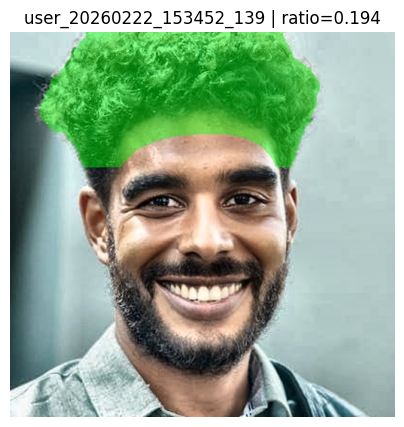

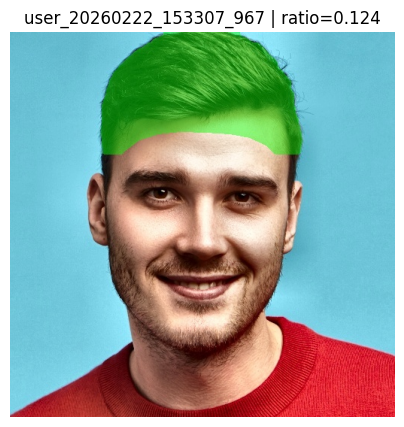

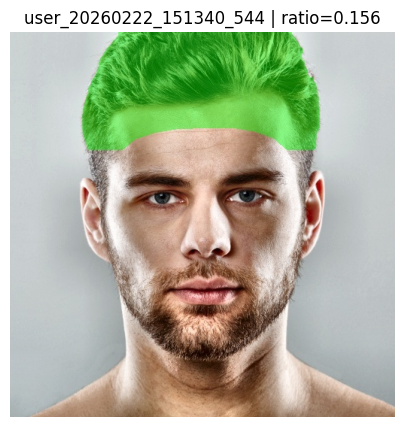

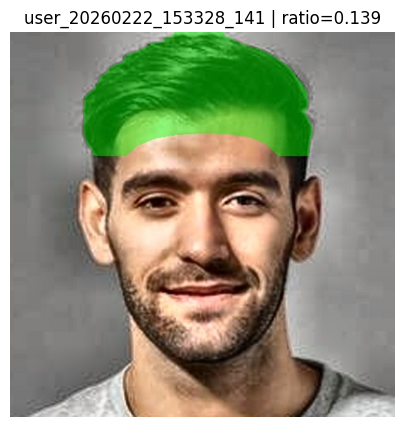

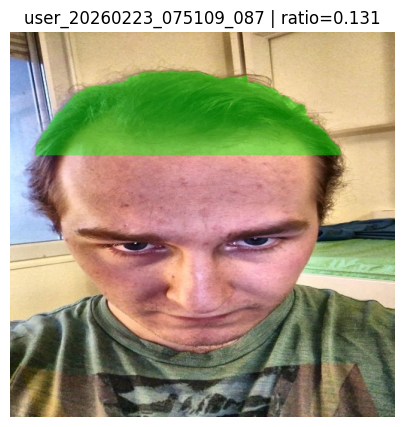

In [29]:
import random, json, cv2, matplotlib.pyplot as plt

cfg = p3.Phase3Config(hair_down=0.08, hair_up=1.00, hair_expand_x=0.30)

samples = random.sample(meta_files, k=min(5, len(meta_files)))
for mpth in samples:
    p3.run_phase3_segmentation_for_meta(base_dir=BASE, meta_path=mpth, config=cfg)
    with open(mpth, "r", encoding="utf-8") as f:
        m = json.load(f)

    overlay = cv2.cvtColor(cv2.imread(os.path.join(BASE, m["mask_overlay_path"])), cv2.COLOR_BGR2RGB)
    r = m.get("mask_quality", {}).get("mask_area_ratio", 0.0)
    plt.figure(figsize=(5,5))
    plt.imshow(overlay); plt.axis("off")
    plt.title(f"{m.get('image_id')} | ratio={r:.3f}")
    plt.show()

In [23]:
cfg = p3.Phase3Config(hair_down=0.08, hair_up=1.00, hair_expand_x=0.30)

ok=fail=0
failed=[]
for mpth in meta_files:
    m = p3.run_phase3_segmentation_for_meta(base_dir=BASE, meta_path=mpth, config=cfg)
    if m.get("mask_error"):
        fail += 1
        failed.append((m.get("image_id"), m.get("mask_error")))
    else:
        ok += 1

print(f"Phase3 DONE ✅ success={ok} fail={fail} total={len(meta_files)}")
if failed:
    print("First failures:", failed[:10])

Phase3 DONE ✅ success=13 fail=0 total=13


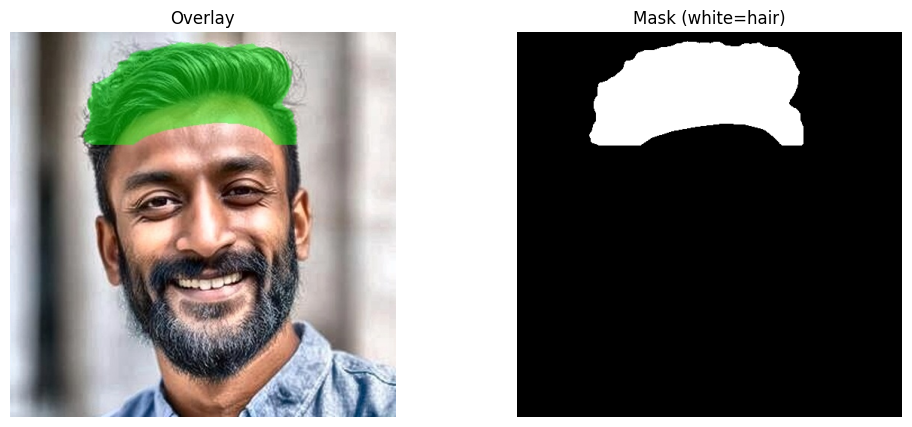

mask_quality: {'mask_area_px': 29060, 'mask_area_ratio': 0.1108551025390625, 'used_face_bbox': True, 'face_bbox_source': 'mediapipe_face_detection', 'used_face_protection': True}
mask_error: None


In [30]:
import random, json, cv2, matplotlib.pyplot as plt

sample_meta = random.choice(meta_files)
with open(sample_meta, "r", encoding="utf-8") as f:
    m = json.load(f)

overlay = cv2.cvtColor(cv2.imread(os.path.join(BASE, m["mask_overlay_path"])), cv2.COLOR_BGR2RGB)
mask = cv2.imread(os.path.join(BASE, m["mask_path"]), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")
plt.subplot(1,2,2); plt.title("Mask (white=hair)"); plt.imshow(mask, cmap="gray"); plt.axis("off")
plt.show()

print("mask_quality:", m.get("mask_quality"))
print("mask_error:", m.get("mask_error"))

In [31]:
from importlib import reload
import modules.phase3_segmentation as p3
reload(p3)

# --- Best MVP settings to finish today ---
cfg = p3.Phase3Config()

cfg.hair_down = 0.02        # critical: stops forehead eating
cfg.hair_expand_x = 0.38    # capture temples/sides
cfg.hair_up = 1.10          # cover top consistently

cfg.enable_face_protection = True
cfg.face_erosion_frac = 0.010   # protect more face (bigger face mask)
cfg.face_blur_frac = 0.008      # feather edges (less "cap" look)

print("Phase3Config loaded:", cfg)

Phase3Config loaded: Phase3Config(model_name='mediapipe_selfie_segmentation_mvp_v2_face_protect', mp_model_selection=1, person_threshold=0.5, morph_open_frac=0.01, morph_close_frac=0.02, hair_expand_x=0.38, hair_up=1.1, hair_down=0.02, enable_face_protection=True, face_erosion_frac=0.01, face_blur_frac=0.008)


In [32]:
import random, json

assert len(meta_files) > 0, "meta_files list is empty. Fix path/listing first."

samples = random.sample(meta_files, k=min(10, len(meta_files)))

for mpth in samples:
    p3.run_phase3_segmentation_for_meta(base_dir=BASE, meta_path=mpth, config=cfg)

    with open(mpth, "r", encoding="utf-8") as f:
        m = json.load(f)

    mq = m.get("mask_quality", {})
    print(
        m.get("image_id"),
        "| err:", m.get("mask_error"),
        "| ratio:", round(float(mq.get("mask_area_ratio", 0.0)), 3),
        "| faceProt:", mq.get("used_face_protection"),
        "| bbox:", mq.get("used_face_bbox"),
    )

user_20260222_153736_798 | err: None | ratio: 0.116 | faceProt: True | bbox: True
user_20260222_151340_544 | err: None | ratio: 0.147 | faceProt: True | bbox: True
user_20260223_075018_627 | err: None | ratio: 0.154 | faceProt: True | bbox: True
user_20260222_153434_876 | err: None | ratio: 0.154 | faceProt: True | bbox: True
user_20260223_075002_778 | err: None | ratio: 0.119 | faceProt: True | bbox: True
user_20260222_153414_647 | err: None | ratio: 0.173 | faceProt: True | bbox: True
user_20260222_153452_139 | err: None | ratio: 0.187 | faceProt: True | bbox: True
user_20260222_153328_141 | err: None | ratio: 0.131 | faceProt: True | bbox: True
user_20260222_050806 | err: None | ratio: 0.128 | faceProt: True | bbox: True
user_20260222_153307_967 | err: None | ratio: 0.117 | faceProt: True | bbox: True


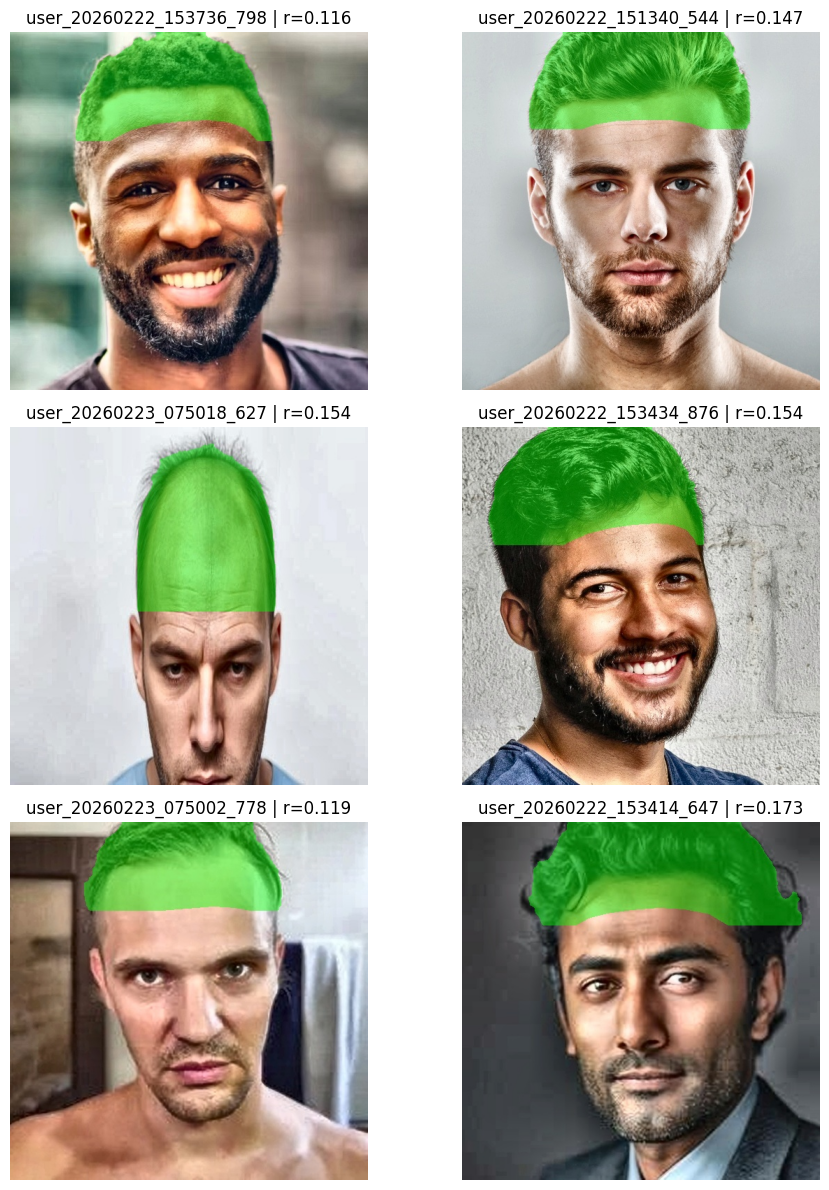

In [33]:
import os, cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))

shown = 0
for i, mpth in enumerate(samples):
    with open(mpth, "r", encoding="utf-8") as f:
        m = json.load(f)

    ovp = m.get("mask_overlay_path")
    if not ovp:
        continue

    ov_abs = os.path.join(BASE, ovp)
    im = cv2.imread(ov_abs)
    if im is None:
        continue

    overlay = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    shown += 1

    plt.subplot(3, 2, shown)
    plt.imshow(overlay)
    plt.axis("off")
    r = m.get("mask_quality", {}).get("mask_area_ratio", 0.0)
    plt.title(f'{m.get("image_id")} | r={r:.3f}')

    if shown >= 6:
        break

plt.tight_layout()
plt.show()